In [1]:
import os
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive", ignore_errors=True)

os.makedirs("/content/drive", exist_ok=True)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q lightgbm xgboost openpyxl

In [3]:
import os
import glob
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

try:
    drive.mount("/content/drive", force_remount=True)
except:
    !fusermount -u /content/drive
    drive.mount("/content/drive", force_remount=True)

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import ParameterGrid

import lightgbm as lgb
import xgboost as xgb

LIGHTGBM_AVAILABLE = False
XGBOOST_AVAILABLE = False

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("LightGBM available.")
except:
    print("LightGBM not available.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost available.")
except:
    print("XGBoost not available.")

BASE_DIR = "/content/drive/MyDrive"
OUTPUT_DIR = os.path.join(BASE_DIR, "model_5_final_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
VALIDATION_WINDOWS = [4, 8, 12]
TEST_WINDOWS = [4, 8, 12]
MIN_TRAIN_WEEKS_CLASSICAL = 20
MIN_TRAIN_WEEKS_ML = 52

print("Output directory:", OUTPUT_DIR)

Mounted at /content/drive
LightGBM available.
XGBoost available.
Output directory: /content/drive/MyDrive/model_5_final_outputs


In [4]:
def find_category_weekly_file(base_dir):
    preferred_names = [
        "model_ready_category_dataset.csv",
        "model_ready_category_level.csv",
        "category_model_ready.csv",
        "model_ready_category.csv",
        "category_weekly.csv"
    ]

    for name in preferred_names:
        path = os.path.join(base_dir, name)
        if os.path.exists(path):
            return path

    csv_files = glob.glob(os.path.join(base_dir, "**/*.csv"), recursive=True)

    scored_files = []

    for path in csv_files:
        filename = os.path.basename(path).lower()

        if any(x in filename for x in [
            "model_1", "model_2", "model_3", "model_4", "model_5",
            "results", "predictions", "validation", "summary", "comparison"
        ]):
            continue

        try:
            sample = pd.read_csv(path, nrows=20)
            cols = [c.lower().strip() for c in sample.columns]

            has_date = any(c in cols for c in ["week", "week_start", "date"])
            has_category = any(c in cols for c in ["product category", "product_category", "category"])
            has_quantity = any(c in cols for c in ["weekly_quantity", "quantity", "qty", "demand", "sales_quantity"])

            score = 0
            if has_date:
                score += 10
            if has_category:
                score += 10
            if has_quantity:
                score += 10
            if "category" in filename:
                score += 5
            if "ready" in filename:
                score += 5
            if "weekly" in filename:
                score += 5

            if score >= 25:
                scored_files.append((score, path))

        except Exception:
            continue

    if not scored_files:
        raise FileNotFoundError(
            "No suitable category-level weekly CSV file found. "
            "Please place the category-level weekly dataset in MyDrive."
        )

    scored_files = sorted(scored_files, reverse=True)

    print("Candidate input files:")
    for score, path in scored_files[:10]:
        print(score, "|", path)

    return scored_files[0][1]

DATA_FILE = find_category_weekly_file(BASE_DIR)
print("\nSelected DATA_FILE:", DATA_FILE)


Selected DATA_FILE: /content/drive/MyDrive/model_ready_category_dataset.csv


In [5]:
df_raw = pd.read_csv(DATA_FILE)

print("\nRaw shape:", df_raw.shape)
print("Raw columns:", df_raw.columns.tolist())
display(df_raw.head())

def detect_column(columns, candidates, label):
    lower_map = {c.lower().strip(): c for c in columns}

    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in columns:
        c_low = c.lower().strip()
        for cand in candidates:
            if cand.lower() in c_low:
                return c

    raise ValueError(f"Could not detect {label}. Available columns: {list(columns)}")


DATE_COL = detect_column(
    df_raw.columns,
    ["week_start", "week", "date"],
    "date/week column"
)

CATEGORY_COL = detect_column(
    df_raw.columns,
    ["product category", "product_category", "category"],
    "category column"
)

TARGET_COL = detect_column(
    df_raw.columns,
    ["weekly_quantity", "quantity", "qty", "demand", "sales_quantity"],
    "target quantity column"
)

print("\nDetected columns:")
print("DATE_COL:", DATE_COL)
print("CATEGORY_COL:", CATEGORY_COL)
print("TARGET_COL:", TARGET_COL)


Raw shape: (6200, 44)
Raw columns: ['Product Category', 'week_start', 'weekly_quantity', 'weekly_revenue', 'transaction_count', 'unique_skus', 'unique_customers', 'avg_unit_price', 'avg_gross_margin_pct', 'negative_margin_share', 'from_china_share', 'from_india_share', 'year', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'split_val_4_test_4', 'split_val_4_test_8', 'split_val_4_test_12', 'split_val_8_test_4', 'split_val_8_test_8', 'split_val_8_test_12', 'split_val_12_test_4', 'split_val_12_test_8', 'split_val_12_test_12']


,Product Category,week_start,weekly_quantity,weekly_revenue,transaction_count,unique_skus,unique_customers,avg_unit_price,avg_gross_margin_pct,negative_margin_share,...,month_cos,split_val_4_test_4,split_val_4_test_8,split_val_4_test_12,split_val_8_test_4,split_val_8_test_8,split_val_8_test_12,split_val_12_test_4,split_val_12_test_8,split_val_12_test_12
0,AΜΠΙΓΙΕ,2023-01-09,9.0,72.66,5.0,5.0,1.0,8.340000,27.650319,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
1,AΜΠΙΓΙΕ,2023-01-16,5.0,48.30,2.0,2.0,2.0,24.150000,63.800814,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
2,AΜΠΙΓΙΕ,2023-01-23,153.0,2287.85,55.0,29.0,6.0,26.957273,69.125848,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
3,AΜΠΙΓΙΕ,2023-01-30,87.0,986.46,21.0,19.0,4.0,16.085714,49.660077,0.000000,...,0.866025,train,train,train,train,train,train,train,train,train
4,AΜΠΙΓΙΕ,2023-02-06,139.0,1237.28,27.0,27.0,4.0,11.554815,34.533068,0.074074,...,0.500000,train,train,train,train,train,train,train,train,train



Detected columns:
DATE_COL: week_start
CATEGORY_COL: Product Category
TARGET_COL: weekly_quantity


In [6]:
df = df_raw.rename(columns={
    DATE_COL: "week",
    CATEGORY_COL: "category",
    TARGET_COL: "y"
}).copy()

df["week"] = pd.to_datetime(df["week"])
df["category"] = df["category"].astype(str)
df["y"] = pd.to_numeric(df["y"], errors="coerce").fillna(0)
df["y"] = df["y"].clip(lower=0)

df = (
    df.groupby(["category", "week"], as_index=False)["y"]
    .sum()
    .sort_values(["category", "week"])
)

all_weeks = sorted(df["week"].unique())
categories = sorted(df["category"].unique())

panel = (
    pd.MultiIndex.from_product([categories, all_weeks], names=["category", "week"])
    .to_frame(index=False)
    .merge(df, on=["category", "week"], how="left")
)

panel["y"] = panel["y"].fillna(0)
panel = panel.sort_values(["category", "week"]).reset_index(drop=True)

print("\nPanel shape:", panel.shape)
print("Categories:", panel["category"].nunique())
print("Weeks:", panel["week"].nunique())
print("Total demand:", panel["y"].sum())
print("Non-zero rows:", (panel["y"] > 0).sum())
print("Zero share:", (panel["y"] == 0).mean())

if panel["y"].sum() <= 0:
    raise ValueError("Target demand is zero after preprocessing. Wrong file or wrong target column detected.")

if panel["category"].nunique() < 2:
    raise ValueError("Too few categories detected. Wrong category column or wrong dataset.")

if panel["week"].nunique() < 50:
    raise ValueError("Too few weeks detected for forecasting. Check the date/week column.")


Panel shape: (6200, 3)
Categories: 40
Weeks: 155
Total demand: 530935.0
Non-zero rows: 2884
Zero share: 0.5348387096774193


In [7]:
audit_rows = []

for cat, g in panel.groupby("category"):
    y = g["y"].values

    audit_rows.append({
        "category": cat,
        "weeks": len(y),
        "total_quantity": y.sum(),
        "mean_quantity": y.mean(),
        "median_quantity": np.median(y),
        "nonzero_weeks": np.sum(y > 0),
        "zero_share": np.mean(y == 0),
        "max_quantity": y.max(),
        "std_quantity": y.std()
    })

audit_df = pd.DataFrame(audit_rows).sort_values("total_quantity", ascending=False)
audit_path = os.path.join(OUTPUT_DIR, "model_5_data_audit.xlsx")
audit_df.to_excel(audit_path, index=False)

print("\nAudit saved:", audit_path)
display(audit_df.head(10))


Audit saved: /content/drive/MyDrive/model_5_final_outputs/model_5_data_audit.xlsx


,category,weeks,total_quantity,mean_quantity,median_quantity,nonzero_weeks,zero_share,max_quantity,std_quantity
34,ΤΣΑΝΤΑ ΓΥΝΑΙΚΕΙΑ,155,169341.0,1092.522581,469.0,154,0.006452,7807.0,1295.380419
22,ΠΑΠΟΥΤΣΙΑ,155,60758.0,391.987097,200.0,132,0.148387,2792.0,485.432697
11,ΚAΣΚΟΛ,155,47001.0,303.232258,3.0,82,0.470968,3733.0,653.976342
0,AΜΠΙΓΙΕ,155,42412.0,273.625806,137.0,152,0.019355,2260.0,354.161894
25,ΠΟΡΤΟΦΟΛΙ ΓΥΝΑΙΚΕΙΟ,155,34662.0,223.625806,109.0,151,0.025806,1787.0,280.984976
6,ΕΣΑΡΠΑ,155,29957.0,193.270968,52.0,132,0.148387,2290.0,366.973732
1,POUCH,155,21817.0,140.754839,63.0,143,0.077419,968.0,198.673938
35,ΤΣΑΝΤΑ ΘΑΛΑΣΣΗΣ,155,19232.0,124.077419,20.0,100,0.354839,869.0,203.230571
10,ΚAΠΕΛΟ,155,15393.0,99.309677,25.0,124,0.200000,1537.0,221.915519
4,ΓΑΝΤΙ ΓΥΝΑΙΚΕΙΟ,155,9572.0,61.754839,0.0,70,0.548387,1034.0,159.360915


In [8]:
def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_true) == 0:
        return np.nan

    mae_model = np.mean(np.abs(y_true - y_pred))

    if len(y_train) <= seasonality:
        scale = np.mean(np.abs(y_train - np.mean(y_train))) if len(y_train) > 1 else np.nan
    else:
        scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))

    if scale is None or np.isnan(scale) or scale == 0:
        scale = np.mean(np.abs(y_train - np.mean(y_train))) if len(y_train) > 1 else np.nan

    if scale is None or np.isnan(scale) or scale == 0:
        return np.nan

    return mae_model / scale

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denom != 0

    if valid.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[valid] - y_pred[valid]) / denom[valid])

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denom

def safe_clip_forecast(pred):
    pred = np.asarray(pred, dtype=float)
    pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    pred = np.maximum(pred, 0)
    return pred


Demand regimes saved: /content/drive/MyDrive/model_5_final_outputs/model_5_demand_regimes.xlsx


,demand_regime,count
0,lumpy,28
1,erratic,8
2,intermittent,4


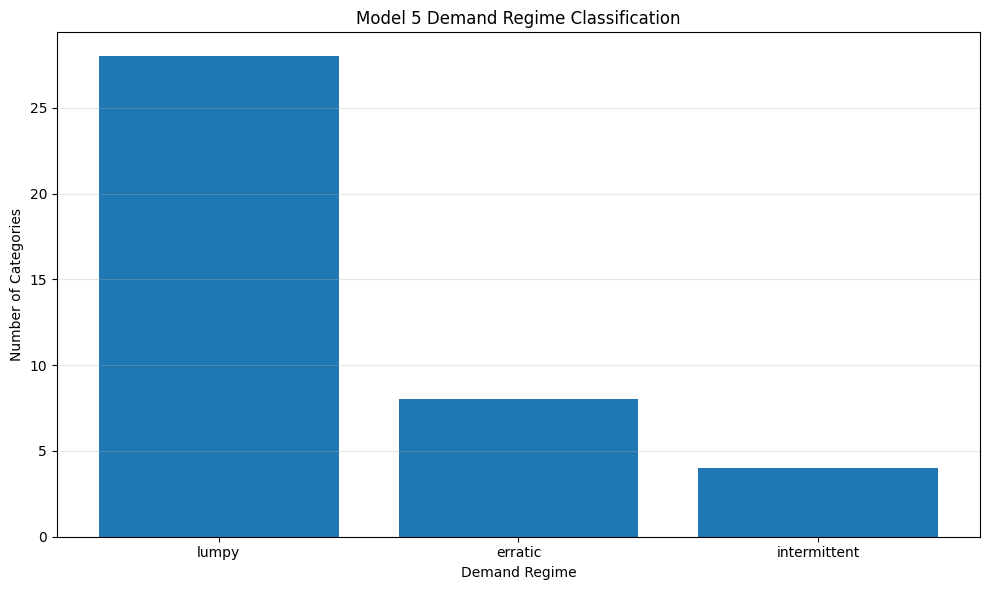

In [9]:
def demand_regime(y):
    y = np.asarray(y, dtype=float)
    n = len(y)

    nonzero = y[y > 0]
    nonzero_count = len(nonzero)

    if n == 0 or nonzero_count == 0:
        return "zero"

    adi = n / nonzero_count

    if nonzero_count <= 1 or np.mean(nonzero) == 0:
        cv2 = np.inf
    else:
        cv2 = (np.std(nonzero) / np.mean(nonzero)) ** 2

    if adi < 1.32 and cv2 < 0.49:
        return "smooth"
    elif adi >= 1.32 and cv2 < 0.49:
        return "intermittent"
    elif adi < 1.32 and cv2 >= 0.49:
        return "erratic"
    else:
        return "lumpy"

regime_rows = []

for cat, g in panel.groupby("category"):
    y = g["y"].values
    nonzero = y[y > 0]
    n = len(y)
    nonzero_count = len(nonzero)

    adi = np.nan if nonzero_count == 0 else n / nonzero_count
    cv2 = np.nan
    if nonzero_count > 1 and np.mean(nonzero) > 0:
        cv2 = (np.std(nonzero) / np.mean(nonzero)) ** 2

    regime_rows.append({
        "category": cat,
        "demand_regime": demand_regime(y),
        "ADI": adi,
        "CV2": cv2,
        "weeks": n,
        "nonzero_weeks": nonzero_count,
        "zero_share": np.mean(y == 0),
        "total_quantity": y.sum()
    })

regime_df = pd.DataFrame(regime_rows)

regime_path = os.path.join(OUTPUT_DIR, "model_5_demand_regimes.xlsx")
regime_df.to_excel(regime_path, index=False)

print("\nDemand regimes saved:", regime_path)
display(regime_df["demand_regime"].value_counts().reset_index())


plt.figure(figsize=(10, 6))
regime_counts = regime_df["demand_regime"].value_counts()
plt.bar(regime_counts.index, regime_counts.values)
plt.title("Model 5 Demand Regime Classification")
plt.xlabel("Demand Regime")
plt.ylabel("Number of Categories")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

regime_plot_path = os.path.join(OUTPUT_DIR, "model_5_demand_regime_classification.png")
plt.savefig(regime_plot_path, dpi=150)
plt.show()

In [10]:
def make_split_scenarios(weeks, validation_windows, test_windows):
    scenarios = []
    weeks = list(sorted(weeks))

    for val_len in validation_windows:
        for test_len in test_windows:
            if len(weeks) <= val_len + test_len + MIN_TRAIN_WEEKS_CLASSICAL:
                continue

            train_weeks = weeks[:-(val_len + test_len)]
            val_weeks = weeks[-(val_len + test_len):-test_len]
            test_weeks = weeks[-test_len:]

            scenarios.append({
                "scenario": f"val_{val_len}_test_{test_len}",
                "val_len": val_len,
                "test_len": test_len,
                "train_weeks": train_weeks,
                "val_weeks": val_weeks,
                "test_weeks": test_weeks
            })

    return scenarios

all_scenarios = make_split_scenarios(
    all_weeks,
    VALIDATION_WINDOWS,
    TEST_WINDOWS
)

print("\nGenerated split scenarios:")
for s in all_scenarios:
    print(
        s["scenario"],
        "| train:", len(s["train_weeks"]),
        "| val:", len(s["val_weeks"]),
        "| test:", len(s["test_weeks"])
    )


Generated split scenarios:
val_4_test_4 | train: 147 | val: 4 | test: 4
val_4_test_8 | train: 143 | val: 4 | test: 8
val_4_test_12 | train: 139 | val: 4 | test: 12
val_8_test_4 | train: 143 | val: 8 | test: 4
val_8_test_8 | train: 139 | val: 8 | test: 8
val_8_test_12 | train: 135 | val: 8 | test: 12
val_12_test_4 | train: 139 | val: 12 | test: 4
val_12_test_8 | train: 135 | val: 12 | test: 8
val_12_test_12 | train: 131 | val: 12 | test: 12


In [11]:
setup_summary = pd.DataFrame([{
    "dataset": DATA_FILE,
    "output_dir": OUTPUT_DIR,
    "date_col_original": DATE_COL,
    "category_col_original": CATEGORY_COL,
    "target_col_original": TARGET_COL,
    "n_categories": panel["category"].nunique(),
    "n_weeks": panel["week"].nunique(),
    "n_rows_panel": len(panel),
    "total_demand": panel["y"].sum(),
    "nonzero_rows": int((panel["y"] > 0).sum()),
    "zero_share": float((panel["y"] == 0).mean()),
    "validation_windows": str(VALIDATION_WINDOWS),
    "test_windows": str(TEST_WINDOWS),
    "min_train_weeks_classical": MIN_TRAIN_WEEKS_CLASSICAL,
    "min_train_weeks_ml": MIN_TRAIN_WEEKS_ML
}])

setup_path = os.path.join(OUTPUT_DIR, "model_5_setup_summary.xlsx")
setup_summary.to_excel(setup_path, index=False)

print("\nSetup summary saved:", setup_path)
print("\nPART 1 completed successfully.")


Setup summary saved: /content/drive/MyDrive/model_5_final_outputs/model_5_setup_summary.xlsx

PART 1 completed successfully.


In [12]:
def forecast_zero(train_y, horizon):
    return np.zeros(horizon)

def forecast_last_value(train_y, horizon):
    if len(train_y) == 0:
        return np.zeros(horizon)
    return np.repeat(train_y[-1], horizon)

def forecast_mean(train_y, horizon):
    if len(train_y) == 0:
        return np.zeros(horizon)
    return np.repeat(np.mean(train_y), horizon)

def forecast_median(train_y, horizon):
    if len(train_y) == 0:
        return np.zeros(horizon)
    return np.repeat(np.median(train_y), horizon)

def forecast_recent_mean(train_y, horizon, window):
    if len(train_y) == 0:
        return np.zeros(horizon)
    recent = train_y[-min(window, len(train_y)):]
    return np.repeat(np.mean(recent), horizon)

def forecast_recent_median(train_y, horizon, window):
    if len(train_y) == 0:
        return np.zeros(horizon)
    recent = train_y[-min(window, len(train_y)):]
    return np.repeat(np.median(recent), horizon)

def forecast_moving_average_recursive(train_y, horizon, window):
    history = list(train_y)
    preds = []

    for _ in range(horizon):
        if len(history) == 0:
            pred = 0
        else:
            recent = history[-min(window, len(history)):]
            pred = np.mean(recent)

        preds.append(pred)
        history.append(pred)

    return np.array(preds)

def forecast_seasonal_naive(train_y, horizon, season_length=52):
    train_y = np.asarray(train_y, dtype=float)

    if len(train_y) < season_length:
        return forecast_recent_mean(train_y, horizon, window=min(8, max(1, len(train_y))))

    seasonal_values = train_y[-season_length:]
    reps = int(np.ceil(horizon / season_length))
    return np.tile(seasonal_values, reps)[:horizon]

def forecast_seasonal_recent_mean(train_y, horizon, season_length=52, seasonal_window=2):
    train_y = np.asarray(train_y, dtype=float)

    if len(train_y) < season_length:
        return forecast_recent_mean(train_y, horizon, window=min(8, max(1, len(train_y))))

    preds = []

    for h in range(horizon):
        seasonal_indices = []
        base_idx = len(train_y) - season_length + h

        for k in range(seasonal_window):
            idx = base_idx - k * season_length
            if 0 <= idx < len(train_y):
                seasonal_indices.append(idx)

        if seasonal_indices:
            pred = np.mean(train_y[seasonal_indices])
        else:
            pred = train_y[-season_length + (h % season_length)]

        preds.append(pred)

    return np.array(preds)

In [13]:
def croston_forecast(train_y, horizon, alpha=0.1, variant="croston"):
    y = np.asarray(train_y, dtype=float)

    if len(y) == 0 or np.all(y == 0):
        return np.zeros(horizon)

    demand = []
    intervals = []
    interval = 0

    for val in y:
        interval += 1
        if val > 0:
            demand.append(val)
            intervals.append(interval)
            interval = 0

    if len(demand) == 0:
        return np.zeros(horizon)

    z = demand[0]
    p = intervals[0]

    for d, q in zip(demand[1:], intervals[1:]):
        z = alpha * d + (1 - alpha) * z
        p = alpha * q + (1 - alpha) * p

    forecast = z / max(p, 1e-8)

    if variant == "sba":
        forecast = forecast * (1 - alpha / 2)

    return np.repeat(max(forecast, 0), horizon)

def tsb_forecast(train_y, horizon, alpha_demand=0.1, alpha_prob=0.1):
    y = np.asarray(train_y, dtype=float)

    if len(y) == 0 or np.all(y == 0):
        return np.zeros(horizon)

    occurrence = (y > 0).astype(float)
    positive = y[y > 0]

    demand_level = positive[0] if len(positive) > 0 else 0
    probability = occurrence[0]

    for val, occ in zip(y, occurrence):
        probability = alpha_prob * occ + (1 - alpha_prob) * probability
        if occ > 0:
            demand_level = alpha_demand * val + (1 - alpha_demand) * demand_level

    forecast = probability * demand_level
    return np.repeat(max(forecast, 0), horizon)

def adida_forecast(train_y, horizon, aggregation_level=4, base_method="mean"):
    y = np.asarray(train_y, dtype=float)

    if len(y) == 0:
        return np.zeros(horizon)

    usable_len = (len(y) // aggregation_level) * aggregation_level

    if usable_len < aggregation_level:
        return forecast_recent_mean(y, horizon, window=min(aggregation_level, len(y)))

    y_trim = y[-usable_len:]
    aggregated = y_trim.reshape(-1, aggregation_level).sum(axis=1)

    if base_method == "mean":
        agg_forecast = np.mean(aggregated)
    elif base_method == "median":
        agg_forecast = np.median(aggregated)
    else:
        agg_forecast = aggregated[-1]

    per_period_forecast = agg_forecast / aggregation_level
    return np.repeat(max(per_period_forecast, 0), horizon)

def imapa_forecast(train_y, horizon, aggregation_levels=(2, 4, 8)):
    preds = []

    for level in aggregation_levels:
        preds.append(adida_forecast(train_y, horizon, aggregation_level=level, base_method="mean"))

    if not preds:
        return np.zeros(horizon)

    return np.mean(preds, axis=0)

In [14]:
CLASSICAL_GRID = []

CLASSICAL_GRID.append({"family": "zero", "name": "zero"})
CLASSICAL_GRID.append({"family": "last_value", "name": "last_value"})
CLASSICAL_GRID.append({"family": "mean", "name": "mean"})
CLASSICAL_GRID.append({"family": "median", "name": "median"})

for window in [2, 4, 8, 12, 26]:
    CLASSICAL_GRID.append({
        "family": "recent_mean",
        "name": f"recent_mean_{window}",
        "window": window
    })
    CLASSICAL_GRID.append({
        "family": "recent_median",
        "name": f"recent_median_{window}",
        "window": window
    })
    CLASSICAL_GRID.append({
        "family": "moving_average_recursive",
        "name": f"moving_average_recursive_{window}",
        "window": window
    })

for season_length in [26, 52]:
    CLASSICAL_GRID.append({
        "family": "seasonal_naive",
        "name": f"seasonal_naive_{season_length}",
        "season_length": season_length
    })

for season_length in [26, 52]:
    for seasonal_window in [1, 2, 3]:
        CLASSICAL_GRID.append({
            "family": "seasonal_recent_mean",
            "name": f"seasonal_recent_mean_s{season_length}_w{seasonal_window}",
            "season_length": season_length,
            "seasonal_window": seasonal_window
        })

for alpha in [0.05, 0.1, 0.2, 0.3]:
    CLASSICAL_GRID.append({
        "family": "croston",
        "name": f"croston_alpha_{alpha}",
        "alpha": alpha,
        "variant": "croston"
    })
    CLASSICAL_GRID.append({
        "family": "croston",
        "name": f"sba_alpha_{alpha}",
        "alpha": alpha,
        "variant": "sba"
    })

for alpha_demand in [0.05, 0.1, 0.2, 0.3]:
    for alpha_prob in [0.05, 0.1, 0.2, 0.3]:
        CLASSICAL_GRID.append({
            "family": "tsb",
            "name": f"tsb_ad{alpha_demand}_ap{alpha_prob}",
            "alpha_demand": alpha_demand,
            "alpha_prob": alpha_prob
        })

for aggregation_level in [2, 4, 8, 12]:
    for base_method in ["mean", "median", "last"]:
        CLASSICAL_GRID.append({
            "family": "adida",
            "name": f"adida_a{aggregation_level}_{base_method}",
            "aggregation_level": aggregation_level,
            "base_method": base_method
        })

CLASSICAL_GRID.append({
    "family": "imapa",
    "name": "imapa_2_4_8",
    "aggregation_levels": (2, 4, 8)
})

CLASSICAL_GRID.append({
    "family": "imapa",
    "name": "imapa_2_4_8_12",
    "aggregation_levels": (2, 4, 8, 12)
})

print("Number of classical/intermittent expert configurations:", len(CLASSICAL_GRID))

Number of classical/intermittent expert configurations: 65


In [15]:
def forecast_from_config(train_y, horizon, config):
    family = config["family"]

    if family == "zero":
        pred = forecast_zero(train_y, horizon)

    elif family == "last_value":
        pred = forecast_last_value(train_y, horizon)

    elif family == "mean":
        pred = forecast_mean(train_y, horizon)

    elif family == "median":
        pred = forecast_median(train_y, horizon)

    elif family == "recent_mean":
        pred = forecast_recent_mean(train_y, horizon, window=config["window"])

    elif family == "recent_median":
        pred = forecast_recent_median(train_y, horizon, window=config["window"])

    elif family == "moving_average_recursive":
        pred = forecast_moving_average_recursive(train_y, horizon, window=config["window"])

    elif family == "seasonal_naive":
        pred = forecast_seasonal_naive(train_y, horizon, season_length=config["season_length"])

    elif family == "seasonal_recent_mean":
        pred = forecast_seasonal_recent_mean(
            train_y,
            horizon,
            season_length=config["season_length"],
            seasonal_window=config["seasonal_window"]
        )

    elif family == "croston":
        pred = croston_forecast(
            train_y,
            horizon,
            alpha=config["alpha"],
            variant=config["variant"]
        )

    elif family == "tsb":
        pred = tsb_forecast(
            train_y,
            horizon,
            alpha_demand=config["alpha_demand"],
            alpha_prob=config["alpha_prob"]
        )

    elif family == "adida":
        pred = adida_forecast(
            train_y,
            horizon,
            aggregation_level=config["aggregation_level"],
            base_method=config["base_method"]
        )

    elif family == "imapa":
        pred = imapa_forecast(
            train_y,
            horizon,
            aggregation_levels=config["aggregation_levels"]
        )

    else:
        pred = np.zeros(horizon)

    return safe_clip_forecast(pred)

In [16]:
def build_ml_supervised_dataset(category_series_df):
    """
    Builds leakage-safe supervised features from one category series.
    Target at time t uses only lagged/rolling values from < t.
    """
    data = category_series_df.copy().sort_values("week").reset_index(drop=True)

    for lag in [1, 2, 4, 8, 12, 26, 52]:
        data[f"lag_{lag}"] = data["y"].shift(lag)

    for window in [4, 8, 12, 26]:
        shifted = data["y"].shift(1)
        data[f"rolling_mean_{window}"] = shifted.rolling(window).mean()
        data[f"rolling_median_{window}"] = shifted.rolling(window).median()
        data[f"rolling_std_{window}"] = shifted.rolling(window).std()
        data[f"rolling_max_{window}"] = shifted.rolling(window).max()
        data[f"recent_positive_ratio_{window}"] = shifted.rolling(window).apply(
            lambda x: np.mean(np.asarray(x) > 0),
            raw=False
        )

    data["week_of_year"] = data["week"].dt.isocalendar().week.astype(int)
    data["month"] = data["week"].dt.month
    data["quarter"] = data["week"].dt.quarter

    data["week_sin"] = np.sin(2 * np.pi * data["week_of_year"] / 52)
    data["week_cos"] = np.cos(2 * np.pi * data["week_of_year"] / 52)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    feature_cols = [
        c for c in data.columns
        if c not in ["category", "week", "y"]
    ]

    data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    return data, feature_cols

def make_future_feature_row(history_y, future_week):
    history_y = list(history_y)
    row = {}

    for lag in [1, 2, 4, 8, 12, 26, 52]:
        row[f"lag_{lag}"] = history_y[-lag] if len(history_y) >= lag else 0

    for window in [4, 8, 12, 26]:
        recent = np.asarray(history_y[-min(window, len(history_y)):], dtype=float)

        if len(recent) == 0:
            recent = np.array([0.0])

        row[f"rolling_mean_{window}"] = np.mean(recent)
        row[f"rolling_median_{window}"] = np.median(recent)
        row[f"rolling_std_{window}"] = np.std(recent)
        row[f"rolling_max_{window}"] = np.max(recent)
        row[f"recent_positive_ratio_{window}"] = np.mean(recent > 0)

    future_week = pd.Timestamp(future_week)
    week_of_year = int(future_week.isocalendar().week)

    row["week_of_year"] = week_of_year
    row["month"] = future_week.month
    row["quarter"] = future_week.quarter

    row["week_sin"] = np.sin(2 * np.pi * week_of_year / 52)
    row["week_cos"] = np.cos(2 * np.pi * week_of_year / 52)
    row["month_sin"] = np.sin(2 * np.pi * future_week.month / 12)
    row["month_cos"] = np.cos(2 * np.pi * future_week.month / 12)

    return pd.DataFrame([row])

In [17]:
ML_GRIDS = {}

ML_GRIDS["random_forest"] = {
    "model_family": ["random_forest"],
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 8],
    "min_samples_leaf": [2, 4]
}

ML_GRIDS["extra_trees"] = {
    "model_family": ["extra_trees"],
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 8],
    "min_samples_leaf": [2, 4]
}

ML_GRIDS["hist_gradient_boosting"] = {
    "model_family": ["hist_gradient_boosting"],
    "max_iter": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_leaf_nodes": [7, 15],
    "l2_regularization": [0.1, 1.0]
}

if LIGHTGBM_AVAILABLE:
    ML_GRIDS["lightgbm_l2"] = {
        "model_family": ["lightgbm_l2"],
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "num_leaves": [7, 15],
        "max_depth": [3, 5],
        "min_child_samples": [5, 10],
        "reg_lambda": [1.0, 3.0]
    }

    ML_GRIDS["lightgbm_poisson"] = {
        "model_family": ["lightgbm_poisson"],
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "num_leaves": [7, 15],
        "max_depth": [3, 5],
        "min_child_samples": [5, 10],
        "reg_lambda": [1.0, 3.0]
    }

    ML_GRIDS["lightgbm_tweedie"] = {
        "model_family": ["lightgbm_tweedie"],
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "num_leaves": [7, 15],
        "max_depth": [3, 5],
        "min_child_samples": [5, 10],
        "reg_lambda": [1.0, 3.0],
        "tweedie_variance_power": [1.1, 1.3, 1.5]
    }

if XGBOOST_AVAILABLE:
    ML_GRIDS["xgboost_l2"] = {
        "model_family": ["xgboost_l2"],
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "max_depth": [2, 3, 5],
        "min_child_weight": [2, 5],
        "reg_lambda": [1.0, 3.0]
    }

    ML_GRIDS["xgboost_poisson"] = {
        "model_family": ["xgboost_poisson"],
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "max_depth": [2, 3, 5],
        "min_child_weight": [2, 5],
        "reg_lambda": [1.0, 3.0]
    }

ML_CONFIGS = []

for family, grid in ML_GRIDS.items():
    for params in ParameterGrid(grid):
        name_parts = [params["model_family"]]
        for k, v in params.items():
            if k != "model_family":
                name_parts.append(f"{k}_{v}")
        params = dict(params)
        params["name"] = "__".join(map(str, name_parts))
        ML_CONFIGS.append(params)

print("Number of ML configurations:", len(ML_CONFIGS))

Number of ML configurations: 456


In [18]:
def fit_ml_model_from_config(config, X_train, y_train):
    family = config["model_family"]

    if family == "random_forest":
        model = RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif family == "extra_trees":
        model = ExtraTreesRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif family == "hist_gradient_boosting":
        model = HistGradientBoostingRegressor(
            max_iter=config["max_iter"],
            learning_rate=config["learning_rate"],
            max_leaf_nodes=config["max_leaf_nodes"],
            l2_regularization=config["l2_regularization"],
            random_state=RANDOM_STATE
        )

    elif family == "lightgbm_l2":
        model = lgb.LGBMRegressor(
            objective="regression",
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            num_leaves=config["num_leaves"],
            max_depth=config["max_depth"],
            min_child_samples=config["min_child_samples"],
            reg_lambda=config["reg_lambda"],
            random_state=RANDOM_STATE,
            verbose=-1
        )

    elif family == "lightgbm_poisson":
        model = lgb.LGBMRegressor(
            objective="poisson",
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            num_leaves=config["num_leaves"],
            max_depth=config["max_depth"],
            min_child_samples=config["min_child_samples"],
            reg_lambda=config["reg_lambda"],
            random_state=RANDOM_STATE,
            verbose=-1
        )

    elif family == "lightgbm_tweedie":
        model = lgb.LGBMRegressor(
            objective="tweedie",
            tweedie_variance_power=config["tweedie_variance_power"],
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            num_leaves=config["num_leaves"],
            max_depth=config["max_depth"],
            min_child_samples=config["min_child_samples"],
            reg_lambda=config["reg_lambda"],
            random_state=RANDOM_STATE,
            verbose=-1
        )

    elif family == "xgboost_l2":
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            min_child_weight=config["min_child_weight"],
            reg_lambda=config["reg_lambda"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif family == "xgboost_poisson":
        model = xgb.XGBRegressor(
            objective="count:poisson",
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            min_child_weight=config["min_child_weight"],
            reg_lambda=config["reg_lambda"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        return None

    model.fit(X_train, y_train)
    return model

def recursive_ml_forecast(model, feature_cols, history_y, future_weeks):
    history = list(history_y)
    preds = []

    for future_week in future_weeks:
        X_next = make_future_feature_row(history, future_week)
        X_next = X_next.reindex(columns=feature_cols).fillna(0)

        pred = model.predict(X_next)[0]
        pred = max(float(pred), 0)

        preds.append(pred)
        history.append(pred)

    return safe_clip_forecast(preds)

In [19]:
def evaluate_ml_configs_for_category(cat_panel, train_weeks, val_weeks):
    """
    Returns validation predictions and scores for ML configs.
    Uses train only for fitting, validation only for model selection.
    """
    train_data = cat_panel[cat_panel["week"].isin(train_weeks)].copy()
    val_data = cat_panel[cat_panel["week"].isin(val_weeks)].copy()

    if len(train_data) < MIN_TRAIN_WEEKS_ML:
        return []

    supervised, feature_cols = build_ml_supervised_dataset(train_data)

    supervised = supervised.dropna(subset=["y"])
    X_train = supervised[feature_cols]
    y_train = supervised["y"]

    if len(X_train) < 20:
        return []

    history_y = train_data["y"].values
    val_y = val_data["y"].values

    results = []

    for config in ML_CONFIGS:
        try:
            model = fit_ml_model_from_config(config, X_train, y_train)

            if model is None:
                continue

            pred = recursive_ml_forecast(
                model=model,
                feature_cols=feature_cols,
                history_y=history_y,
                future_weeks=val_weeks
            )

            results.append({
                "name": config["name"],
                "family": config["model_family"],
                "config": config,
                "prediction": pred,
                "val_mase": mase(val_y, pred, history_y, seasonality=1),
                "val_smape": smape(val_y, pred),
                "val_wape": wape(val_y, pred)
            })

        except Exception:
            continue

    return results

In [20]:
def evaluate_classical_configs_for_category(cat_panel, train_weeks, val_weeks):
    train_data = cat_panel[cat_panel["week"].isin(train_weeks)].copy()
    val_data = cat_panel[cat_panel["week"].isin(val_weeks)].copy()

    train_y = train_data["y"].values
    val_y = val_data["y"].values

    results = []

    for config in CLASSICAL_GRID:
        try:
            pred = forecast_from_config(train_y, len(val_weeks), config)

            results.append({
                "name": config["name"],
                "family": config["family"],
                "config": config,
                "prediction": pred,
                "val_mase": mase(val_y, pred, train_y, seasonality=1),
                "val_smape": smape(val_y, pred),
                "val_wape": wape(val_y, pred)
            })

        except Exception:
            continue

    return results

In [21]:
def evaluate_all_experts_for_category(cat_panel, train_weeks, val_weeks):
    classical_results = evaluate_classical_configs_for_category(
        cat_panel,
        train_weeks,
        val_weeks
    )

    ml_results = evaluate_ml_configs_for_category(
        cat_panel,
        train_weeks,
        val_weeks
    )

    all_results = classical_results + ml_results

    clean_results = []
    for r in all_results:
        if r["prediction"] is None:
            continue
        if np.any(pd.isna(r["prediction"])):
            continue
        if np.isnan(r["val_mase"]):
            continue
        clean_results.append(r)

    clean_results = sorted(clean_results, key=lambda x: x["val_mase"])
    return clean_results

In [22]:
def make_inverse_error_weights(results, top_n):
    selected = results[:top_n]

    weights = []
    for r in selected:
        err = r["val_mase"]
        if err <= 0 or np.isnan(err):
            err = 1e-6
        weights.append(1 / err)

    weights = np.array(weights)
    weights = weights / weights.sum()

    return selected, weights

def ensemble_from_results(results, top_n):
    selected, weights = make_inverse_error_weights(results, top_n)

    preds = np.vstack([r["prediction"] for r in selected])
    ensemble_pred = np.average(preds, axis=0, weights=weights)

    return safe_clip_forecast(ensemble_pred), selected, weights

def evaluate_strategy_candidates(results, val_y, train_y):
    strategies = []

    if len(results) == 0:
        return []

    best = results[0]
    strategies.append({
        "strategy": "single_best",
        "prediction": best["prediction"],
        "members": [best],
        "weights": [1.0],
        "strategy_val_mase": mase(val_y, best["prediction"], train_y, seasonality=1)
    })

    if len(results) >= 3:
        pred, selected, weights = ensemble_from_results(results, top_n=3)
        strategies.append({
            "strategy": "top3_weighted",
            "prediction": pred,
            "members": selected,
            "weights": weights,
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1)
        })

    if len(results) >= 5:
        pred, selected, weights = ensemble_from_results(results, top_n=5)
        strategies.append({
            "strategy": "top5_weighted",
            "prediction": pred,
            "members": selected,
            "weights": weights,
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1)
        })

    diverse_members = []
    used_families = set()

    for r in results:
        if r["family"] not in used_families:
            diverse_members.append(r)
            used_families.add(r["family"])
        if len(diverse_members) >= 5:
            break

    if len(diverse_members) >= 2:
        weights = np.array([1 / max(r["val_mase"], 1e-6) for r in diverse_members])
        weights = weights / weights.sum()
        preds = np.vstack([r["prediction"] for r in diverse_members])
        pred = np.average(preds, axis=0, weights=weights)

        strategies.append({
            "strategy": "family_diverse_weighted",
            "prediction": safe_clip_forecast(pred),
            "members": diverse_members,
            "weights": weights,
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1)
        })

    strategies = sorted(strategies, key=lambda x: x["strategy_val_mase"])
    return strategies

print("\nPART 2 completed successfully.")
print("Classical/intermittent configurations:", len(CLASSICAL_GRID))
print("ML configurations:", len(ML_CONFIGS))


PART 2 completed successfully.
Classical/intermittent configurations: 65
ML configurations: 456


In [23]:
def validation_calibration_factor(y_val, pred_val, lower=0.50, upper=1.50):
    y_val = np.asarray(y_val, dtype=float)
    pred_val = np.asarray(pred_val, dtype=float)

    actual_sum = np.sum(y_val)
    pred_sum = np.sum(pred_val)

    if pred_sum <= 0:
        return 1.0

    raw_factor = actual_sum / pred_sum
    factor = np.clip(raw_factor, lower, upper)

    return float(factor)


def calibrated_prediction(pred, factor):
    pred = np.asarray(pred, dtype=float)
    return safe_clip_forecast(pred * factor)

In [24]:
def evaluate_strategy_candidates_calibrated(results, val_y, train_y):
    strategies = []

    if len(results) == 0:
        return []

    calibrated_results = []

    for r in results:
        factor = validation_calibration_factor(
            y_val=val_y,
            pred_val=r["prediction"],
            lower=0.50,
            upper=1.50
        )

        pred_cal = calibrated_prediction(r["prediction"], factor)
        val_mase_cal = mase(val_y, pred_cal, train_y, seasonality=1)
        val_smape_cal = smape(val_y, pred_cal)
        val_wape_cal = wape(val_y, pred_cal)

        r_cal = dict(r)
        r_cal["calibration_factor"] = factor
        r_cal["prediction_calibrated"] = pred_cal
        r_cal["val_mase_calibrated"] = val_mase_cal
        r_cal["val_smape_calibrated"] = val_smape_cal
        r_cal["val_wape_calibrated"] = val_wape_cal

        calibrated_results.append(r_cal)

    calibrated_results = sorted(
        calibrated_results,
        key=lambda x: x["val_mase_calibrated"]
    )

    best = calibrated_results[0]

    strategies.append({
        "strategy": "single_best_calibrated",
        "prediction": best["prediction_calibrated"],
        "members": [best],
        "weights": [1.0],
        "calibration_factors": [best["calibration_factor"]],
        "strategy_val_mase": mase(val_y, best["prediction_calibrated"], train_y, seasonality=1),
        "strategy_val_smape": smape(val_y, best["prediction_calibrated"]),
        "strategy_val_wape": wape(val_y, best["prediction_calibrated"])
    })

    if len(calibrated_results) >= 3:
        selected, weights = make_inverse_error_weights_calibrated(calibrated_results, top_n=3)
        pred = ensemble_from_calibrated_results(selected, weights)

        strategies.append({
            "strategy": "top3_weighted_calibrated",
            "prediction": pred,
            "members": selected,
            "weights": weights,
            "calibration_factors": [m["calibration_factor"] for m in selected],
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1),
            "strategy_val_smape": smape(val_y, pred),
            "strategy_val_wape": wape(val_y, pred)
        })

    if len(calibrated_results) >= 5:
        selected, weights = make_inverse_error_weights_calibrated(calibrated_results, top_n=5)
        pred = ensemble_from_calibrated_results(selected, weights)

        strategies.append({
            "strategy": "top5_weighted_calibrated",
            "prediction": pred,
            "members": selected,
            "weights": weights,
            "calibration_factors": [m["calibration_factor"] for m in selected],
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1),
            "strategy_val_smape": smape(val_y, pred),
            "strategy_val_wape": wape(val_y, pred)
        })

    diverse_members = []
    used_families = set()

    for r in calibrated_results:
        if r["family"] not in used_families:
            diverse_members.append(r)
            used_families.add(r["family"])
        if len(diverse_members) >= 5:
            break

    if len(diverse_members) >= 2:
        errors = np.array([
            max(r["val_mase_calibrated"], 1e-6)
            for r in diverse_members
        ])
        weights = 1 / errors
        weights = weights / weights.sum()

        pred = ensemble_from_calibrated_results(diverse_members, weights)

        strategies.append({
            "strategy": "family_diverse_weighted_calibrated",
            "prediction": pred,
            "members": diverse_members,
            "weights": weights,
            "calibration_factors": [m["calibration_factor"] for m in diverse_members],
            "strategy_val_mase": mase(val_y, pred, train_y, seasonality=1),
            "strategy_val_smape": smape(val_y, pred),
            "strategy_val_wape": wape(val_y, pred)
        })

    strategies = sorted(strategies, key=lambda x: x["strategy_val_mase"])
    return strategies


def make_inverse_error_weights_calibrated(results, top_n):
    selected = results[:top_n]

    weights = []
    for r in selected:
        err = r["val_mase_calibrated"]
        if err <= 0 or np.isnan(err):
            err = 1e-6
        weights.append(1 / err)

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    return selected, weights

def ensemble_from_calibrated_results(selected, weights):
    preds = np.vstack([r["prediction_calibrated"] for r in selected])
    ensemble_pred = np.average(preds, axis=0, weights=weights)
    return safe_clip_forecast(ensemble_pred)

In [25]:
def refit_and_forecast_selected_member_calibrated(cat_panel, selected_member, train_val_weeks, test_weeks):
    config = selected_member["config"]
    family = selected_member["family"]
    factor = selected_member.get("calibration_factor", 1.0)

    train_val_data = cat_panel[cat_panel["week"].isin(train_val_weeks)].copy()
    train_val_y = train_val_data["y"].values

    if family in [
        "zero", "last_value", "mean", "median", "recent_mean", "recent_median",
        "moving_average_recursive", "seasonal_naive", "seasonal_recent_mean",
        "croston", "tsb", "adida", "imapa"
    ]:
        pred = forecast_from_config(train_val_y, len(test_weeks), config)
        return calibrated_prediction(pred, factor)

    supervised, feature_cols = build_ml_supervised_dataset(train_val_data)
    supervised = supervised.dropna(subset=["y"])

    X_train = supervised[feature_cols]
    y_train = supervised["y"]

    if len(X_train) < 20:
        pred = forecast_recent_mean(train_val_y, len(test_weeks), window=8)
        return calibrated_prediction(pred, factor)

    model = fit_ml_model_from_config(config, X_train, y_train)

    if model is None:
        pred = forecast_recent_mean(train_val_y, len(test_weeks), window=8)
        return calibrated_prediction(pred, factor)

    pred = recursive_ml_forecast(
        model=model,
        feature_cols=feature_cols,
        history_y=train_val_y,
        future_weeks=test_weeks
    )

    return calibrated_prediction(pred, factor)

def refit_and_forecast_strategy_calibrated(cat_panel, selected_strategy, train_val_weeks, test_weeks):
    members = selected_strategy["members"]
    weights = np.asarray(selected_strategy["weights"], dtype=float)

    test_member_preds = []

    for member in members:
        pred = refit_and_forecast_selected_member_calibrated(
            cat_panel=cat_panel,
            selected_member=member,
            train_val_weeks=train_val_weeks,
            test_weeks=test_weeks
        )
        test_member_preds.append(pred)

    test_member_preds = np.vstack(test_member_preds)

    if len(weights) != len(test_member_preds):
        weights = np.ones(len(test_member_preds)) / len(test_member_preds)

    weights = weights / weights.sum()

    final_pred = np.average(test_member_preds, axis=0, weights=weights)

    return safe_clip_forecast(final_pred)

In [26]:
all_validation_rows = []
all_strategy_rows = []
all_test_rows = []
all_prediction_rows = []
all_category_rows = []

for scenario in all_scenarios:
    scenario_name = scenario["scenario"]
    train_weeks = scenario["train_weeks"]
    val_weeks = scenario["val_weeks"]
    test_weeks = scenario["test_weeks"]

    print("Running scenario:", scenario_name)
    print("Train weeks:", len(train_weeks), "| Validation weeks:", len(val_weeks), "| Test weeks:", len(test_weeks))

    scenario_category_results = []

    for cat in categories:
        cat_panel = panel[panel["category"] == cat].copy().sort_values("week")

        train_data = cat_panel[cat_panel["week"].isin(train_weeks)]
        val_data = cat_panel[cat_panel["week"].isin(val_weeks)]
        test_data = cat_panel[cat_panel["week"].isin(test_weeks)]

        train_y = train_data["y"].values
        val_y = val_data["y"].values
        test_y = test_data["y"].values

        if len(train_y) < MIN_TRAIN_WEEKS_CLASSICAL:
            continue

        if len(val_y) != len(val_weeks) or len(test_y) != len(test_weeks):
            continue

        regime = demand_regime(train_y)

        expert_results = evaluate_all_experts_for_category(
            cat_panel=cat_panel,
            train_weeks=train_weeks,
            val_weeks=val_weeks
        )

        if len(expert_results) == 0:
            continue

        expert_results_with_calibration = []

        for r in expert_results:
            factor = validation_calibration_factor(
                y_val=val_y,
                pred_val=r["prediction"],
                lower=0.50,
                upper=1.50
            )

            pred_cal = calibrated_prediction(r["prediction"], factor)

            r_cal = dict(r)
            r_cal["calibration_factor"] = factor
            r_cal["prediction_calibrated"] = pred_cal
            r_cal["val_mase_calibrated"] = mase(val_y, pred_cal, train_y, seasonality=1)
            r_cal["val_smape_calibrated"] = smape(val_y, pred_cal)
            r_cal["val_wape_calibrated"] = wape(val_y, pred_cal)

            expert_results_with_calibration.append(r_cal)

        expert_results_with_calibration = sorted(
            expert_results_with_calibration,
            key=lambda x: x["val_mase_calibrated"]
        )

        for rank, r in enumerate(expert_results_with_calibration, start=1):
            all_validation_rows.append({
                "scenario": scenario_name,
                "category": cat,
                "demand_regime": regime,
                "rank": rank,
                "expert_name": r["name"],
                "expert_family": r["family"],
                "val_mase_original": r["val_mase"],
                "val_smape_original": r["val_smape"],
                "val_wape_original": r["val_wape"],
                "calibration_factor": r["calibration_factor"],
                "val_mase_calibrated": r["val_mase_calibrated"],
                "val_smape_calibrated": r["val_smape_calibrated"],
                "val_wape_calibrated": r["val_wape_calibrated"],
                "config": str(r["config"])
            })

        strategy_results = evaluate_strategy_candidates_calibrated(
            results=expert_results,
            val_y=val_y,
            train_y=train_y
        )

        if len(strategy_results) == 0:
            continue

        for rank, s in enumerate(strategy_results, start=1):
            all_strategy_rows.append({
                "scenario": scenario_name,
                "category": cat,
                "demand_regime": regime,
                "rank": rank,
                "strategy": s["strategy"],
                "strategy_val_mase": s["strategy_val_mase"],
                "strategy_val_smape": s["strategy_val_smape"],
                "strategy_val_wape": s["strategy_val_wape"],
                "members": " | ".join([m["name"] for m in s["members"]]),
                "weights": " | ".join([str(round(float(w), 5)) for w in s["weights"]]),
                "calibration_factors": " | ".join([str(round(float(f), 5)) for f in s["calibration_factors"]])
            })

        selected_strategy = strategy_results[0]

        train_val_weeks = train_weeks + val_weeks

        test_pred = refit_and_forecast_strategy_calibrated(
            cat_panel=cat_panel,
            selected_strategy=selected_strategy,
            train_val_weeks=train_val_weeks,
            test_weeks=test_weeks
        )

        train_val_y = cat_panel[cat_panel["week"].isin(train_val_weeks)]["y"].values

        test_mase = mase(test_y, test_pred, train_val_y, seasonality=1)
        test_smape = smape(test_y, test_pred)
        test_wape = wape(test_y, test_pred)
        test_mae = mean_absolute_error(test_y, test_pred)

        actual_sum = np.sum(test_y)
        forecast_sum = np.sum(test_pred)

        category_result = {
            "scenario": scenario_name,
            "category": cat,
            "demand_regime": regime,
            "selected_strategy": selected_strategy["strategy"],
            "selected_members": " | ".join([m["name"] for m in selected_strategy["members"]]),
            "selected_weights": " | ".join([str(round(float(w), 5)) for w in selected_strategy["weights"]]),
            "selected_calibration_factors": " | ".join([str(round(float(f), 5)) for f in selected_strategy["calibration_factors"]]),
            "validation_mase": selected_strategy["strategy_val_mase"],
            "test_mase": test_mase,
            "test_smape": test_smape,
            "test_wape": test_wape,
            "test_mae": test_mae,
            "actual_test_sum": actual_sum,
            "forecast_test_sum": forecast_sum
        }

        scenario_category_results.append(category_result)
        all_category_rows.append(category_result)

        for week, actual, pred in zip(test_weeks, test_y, test_pred):
            all_prediction_rows.append({
                "scenario": scenario_name,
                "category": cat,
                "week": week,
                "actual": actual,
                "forecast": pred,
                "demand_regime": regime,
                "selected_strategy": selected_strategy["strategy"],
                "selected_members": category_result["selected_members"],
                "selected_calibration_factors": category_result["selected_calibration_factors"]
            })

    scenario_df = pd.DataFrame(scenario_category_results)

    if len(scenario_df) > 0:
        scenario_summary = {
            "scenario": scenario_name,
            "val_len": scenario["val_len"],
            "test_len": scenario["test_len"],
            "mean_test_mase": scenario_df["test_mase"].mean(),
            "median_test_mase": scenario_df["test_mase"].median(),
            "mean_test_smape": scenario_df["test_smape"].mean(),
            "mean_test_wape": scenario_df["test_wape"].mean(),
            "mean_test_mae": scenario_df["test_mae"].mean(),
            "actual_total": scenario_df["actual_test_sum"].sum(),
            "forecast_total": scenario_df["forecast_test_sum"].sum(),
            "n_categories": scenario_df["category"].nunique()
        }

        all_test_rows.append(scenario_summary)

        print("Scenario mean MASE:", round(scenario_summary["mean_test_mase"], 4))
        print("Scenario median MASE:", round(scenario_summary["median_test_mase"], 4))

Running scenario: val_4_test_4
Train weeks: 147 | Validation weeks: 4 | Test weeks: 4
Scenario mean MASE: 0.202
Scenario median MASE: 0.1607
Running scenario: val_4_test_8
Train weeks: 143 | Validation weeks: 4 | Test weeks: 8
Scenario mean MASE: 0.7583
Scenario median MASE: 0.3096
Running scenario: val_4_test_12
Train weeks: 139 | Validation weeks: 4 | Test weeks: 12
Scenario mean MASE: 1.22
Scenario median MASE: 0.4763
Running scenario: val_8_test_4
Train weeks: 143 | Validation weeks: 8 | Test weeks: 4
Scenario mean MASE: 0.2059
Scenario median MASE: 0.1541
Running scenario: val_8_test_8
Train weeks: 139 | Validation weeks: 8 | Test weeks: 8
Scenario mean MASE: 0.6214
Scenario median MASE: 0.346
Running scenario: val_8_test_12
Train weeks: 135 | Validation weeks: 8 | Test weeks: 12
Scenario mean MASE: 0.9895
Scenario median MASE: 0.4741
Running scenario: val_12_test_4
Train weeks: 139 | Validation weeks: 12 | Test weeks: 4
Scenario mean MASE: 0.339
Scenario median MASE: 0.2777
Runni

In [27]:
validation_results_df = pd.DataFrame(all_validation_rows)
strategy_results_df = pd.DataFrame(all_strategy_rows)
test_results_df = pd.DataFrame(all_test_rows)
category_results_df = pd.DataFrame(all_category_rows)
predictions_df = pd.DataFrame(all_prediction_rows)

category_mean_results_df = (
    category_results_df
    .groupby("category", as_index=False)
    .agg(
        mean_test_mase=("test_mase", "mean"),
        median_test_mase=("test_mase", "median"),
        mean_test_smape=("test_smape", "mean"),
        mean_test_wape=("test_wape", "mean"),
        mean_test_mae=("test_mae", "mean"),
        actual_total=("actual_test_sum", "sum"),
        forecast_total=("forecast_test_sum", "sum")
    )
    .sort_values("mean_test_mase", ascending=False)
)

expert_selection_counts_df = (
    category_results_df["selected_members"]
    .str.split(" \\| ")
    .explode()
    .value_counts()
    .reset_index()
)

expert_selection_counts_df.columns = ["expert_name", "selection_count"]

strategy_selection_counts_df = (
    category_results_df["selected_strategy"]
    .value_counts()
    .reset_index()
)

strategy_selection_counts_df.columns = ["strategy", "selection_count"]

regime_counts_df = (
    category_results_df[["category", "demand_regime"]]
    .drop_duplicates()
    ["demand_regime"]
    .value_counts()
    .reset_index()
)

regime_counts_df.columns = ["demand_regime", "category_count"]

overall_summary_df = pd.DataFrame([{
    "overall_mean_test_mase": category_results_df["test_mase"].mean(),
    "overall_median_test_mase": category_results_df["test_mase"].median(),
    "overall_mean_test_mae": category_results_df["test_mae"].mean(),
    "overall_mean_test_smape": category_results_df["test_smape"].mean(),
    "overall_actual_total": category_results_df["actual_test_sum"].sum(),
    "overall_forecast_total": category_results_df["forecast_test_sum"].sum()
}])

In [28]:
validation_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_validation_expert_results.csv"), index=False)
strategy_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_strategy_experiment_results.csv"), index=False)
test_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_test_results.csv"), index=False)
category_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_category_results.csv"), index=False)
category_mean_results_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_category_mean_results.csv"), index=False)
predictions_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_predictions.csv"), index=False)
expert_selection_counts_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_expert_selection_counts.csv"), index=False)
strategy_selection_counts_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_strategy_selection_counts.csv"), index=False)
regime_counts_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_regime_counts.csv"), index=False)
overall_summary_df.to_csv(os.path.join(OUTPUT_DIR, "model_5_overall_summary.csv"), index=False)

with pd.ExcelWriter(os.path.join(OUTPUT_DIR, "model_5_all_results.xlsx")) as writer:
    overall_summary_df.to_excel(writer, sheet_name="overall_summary", index=False)
    test_results_df.to_excel(writer, sheet_name="scenario_results", index=False)
    category_results_df.to_excel(writer, sheet_name="category_results", index=False)
    category_mean_results_df.to_excel(writer, sheet_name="category_mean", index=False)
    validation_results_df.to_excel(writer, sheet_name="validation_experts", index=False)
    strategy_results_df.to_excel(writer, sheet_name="strategy_experiments", index=False)
    expert_selection_counts_df.to_excel(writer, sheet_name="expert_counts", index=False)
    strategy_selection_counts_df.to_excel(writer, sheet_name="strategy_counts", index=False)
    regime_counts_df.to_excel(writer, sheet_name="regime_counts", index=False)

experiment_log = {
    "model": "Model 5 - Validation-Calibrated Intermittent Demand + ML Expert Ensemble",
    "data_file": DATA_FILE,
    "output_dir": OUTPUT_DIR,
    "forecasting_level": "Product Category weekly demand",
    "selection_method": "Validation-only expert, strategy and calibration selection",
    "test_policy": "Test set evaluated once after validation selection",
    "classical_configs": len(CLASSICAL_GRID),
    "ml_configs": len(ML_CONFIGS),
    "calibration": {
        "method": "Validation-based multiplicative level calibration",
        "lower_bound": 0.50,
        "upper_bound": 1.50,
        "test_data_used": False
    },
    "strategies": [
        "single_best_calibrated",
        "top3_weighted_calibrated",
        "top5_weighted_calibrated",
        "family_diverse_weighted_calibrated"
    ],
    "scenarios": [
        {
            "scenario": s["scenario"],
            "val_len": s["val_len"],
            "test_len": s["test_len"]
        }
        for s in all_scenarios
    ],
    "leakage_controls": [
        "Chronological train-validation-test split",
        "Expert selection based only on validation metrics",
        "Calibration factor estimated only from validation period",
        "Final test evaluation performed once after selection",
        "ML features use only lagged and rolling past demand",
        "Recursive ML forecasting prevents use of future test actuals"
    ]
}

with open(os.path.join(OUTPUT_DIR, "model_5_experiment_log.json"), "w") as f:
    json.dump(experiment_log, f, indent=4)

In [29]:
print("\nMODEL 5 FINAL CALIBRATED SUMMARY")
display(overall_summary_df)

print("\nScenario results:")
display(test_results_df)

print("\nOverall mean test MASE:", overall_summary_df["overall_mean_test_mase"].iloc[0])
print("Overall median test MASE:", overall_summary_df["overall_median_test_mase"].iloc[0])

print("\nWorst categories:")
display(category_mean_results_df.head(10))

print("\nExpert selection counts:")
display(expert_selection_counts_df.head(20))

print("\nStrategy selection counts:")
display(strategy_selection_counts_df)

print("\nRegime counts:")
display(regime_counts_df)


MODEL 5 FINAL CALIBRATED SUMMARY


,overall_mean_test_mase,overall_median_test_mase,overall_mean_test_mae,overall_mean_test_smape,overall_actual_total,overall_forecast_total
0,0.690763,0.235492,37.963671,1.507079,79626.0,192344.018757



Scenario results:


,scenario,val_len,test_len,mean_test_mase,median_test_mase,mean_test_smape,mean_test_wape,mean_test_mae,actual_total,forecast_total,n_categories
0,val_4_test_4,4,4,0.201958,0.160652,1.619422,2.056722,13.102760,1649.0,1592.902250,39
1,val_4_test_8,4,8,0.758291,0.309605,1.475405,10.039424,35.565870,3951.0,13255.002776,39
2,val_4_test_12,4,12,1.219964,0.476281,1.432907,1.798943,73.768160,20942.0,53248.613564,39
3,val_8_test_4,8,4,0.205863,0.154116,1.517113,1.784467,12.710109,1649.0,1989.583276,39
4,val_8_test_8,8,8,0.621408,0.346020,1.559341,4.180589,39.742736,3951.0,14931.300177,39
5,val_8_test_12,8,12,0.989499,0.474068,1.442819,1.485632,61.650467,20942.0,46830.265422,39
6,val_12_test_4,12,4,0.338972,0.277749,1.532010,3.093104,16.641466,1649.0,2946.724092,39
7,val_12_test_8,12,8,0.811914,0.219479,1.555968,10.851262,31.806242,3951.0,12542.761911,39
8,val_12_test_12,12,12,1.069002,0.377848,1.438776,1.621334,56.685232,20942.0,45006.865288,39



Overall mean test MASE: 0.6907634448105059
Overall median test MASE: 0.2354920786707154

Worst categories:


...

,expert_name,selection_count
0,zero,140
1,seasonal_recent_mean_s26_w2,19
2,seasonal_naive_52,17
3,seasonal_recent_mean_s52_w2,12
4,seasonal_recent_mean_s26_w3,12
5,hist_gradient_boosting__l2_regularization_0.1_...,8
6,hist_gradient_boosting__l2_regularization_1.0_...,8
7,lightgbm_l2__learning_rate_0.05__max_depth_5__...,8
8,seasonal_naive_26,8
9,seasonal_recent_mean_s52_w1,7



Strategy selection counts:


,strategy,selection_count
0,single_best_calibrated,259
1,top3_weighted_calibrated,46
2,top5_weighted_calibrated,30
3,family_diverse_weighted_calibrated,16



Regime counts:


,demand_regime,category_count
0,lumpy,27
1,erratic,8
2,intermittent,4


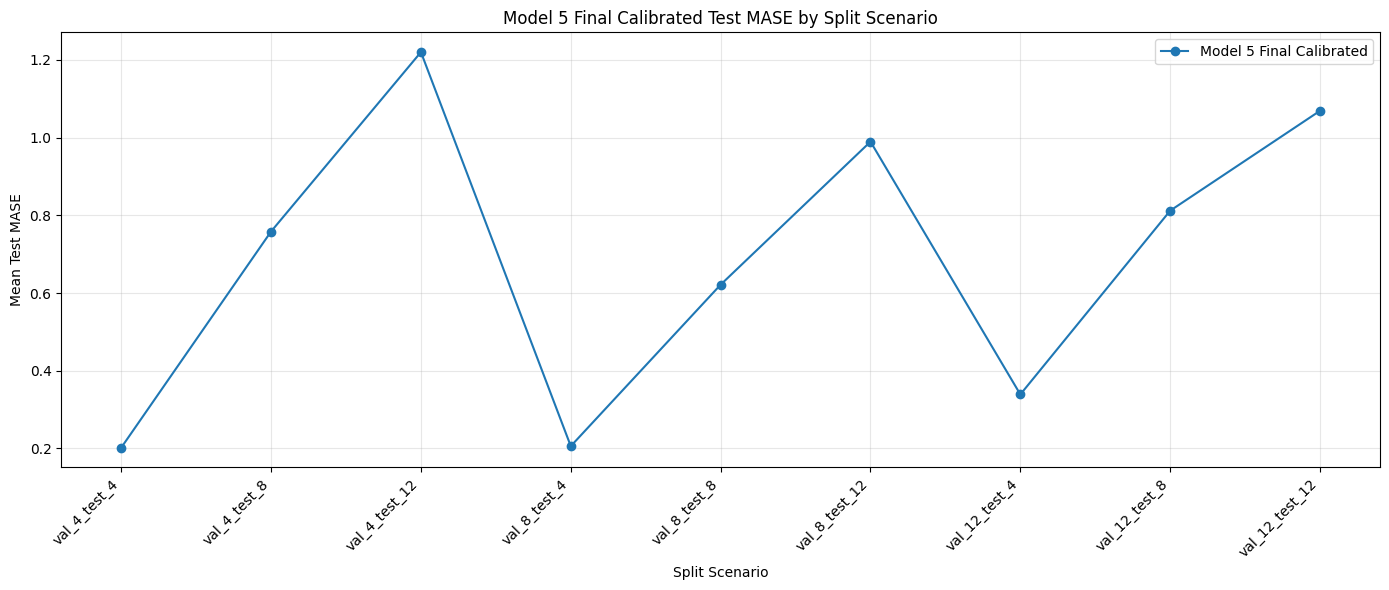

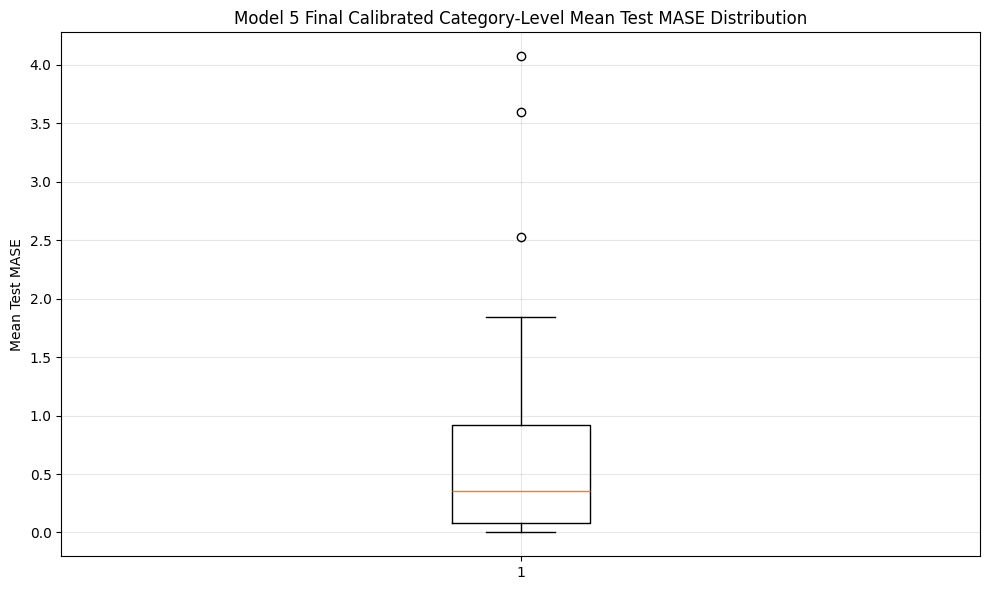

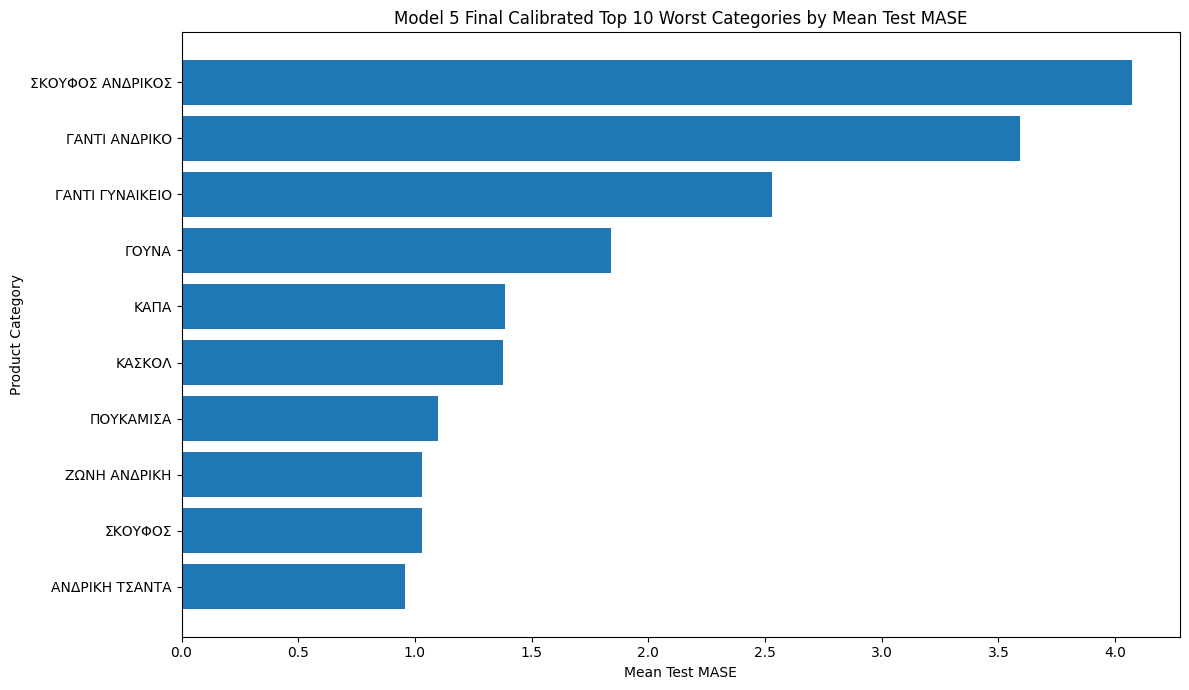

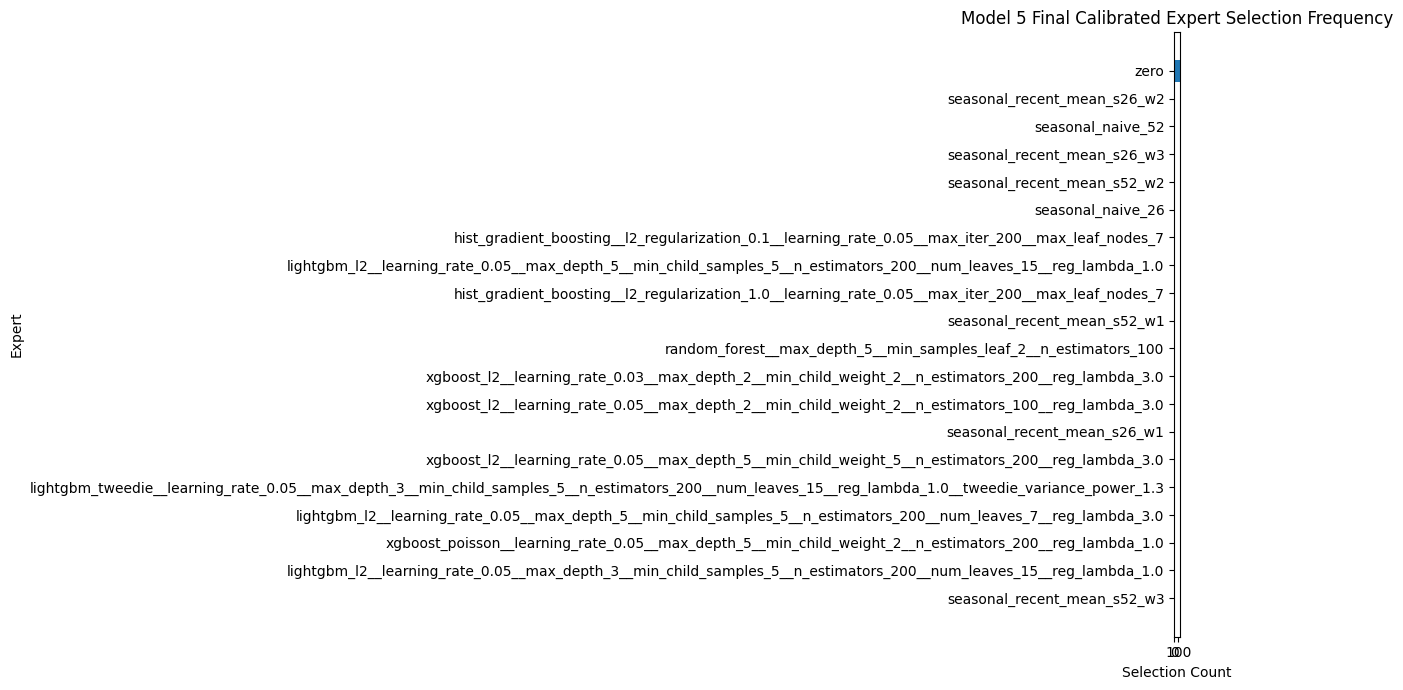

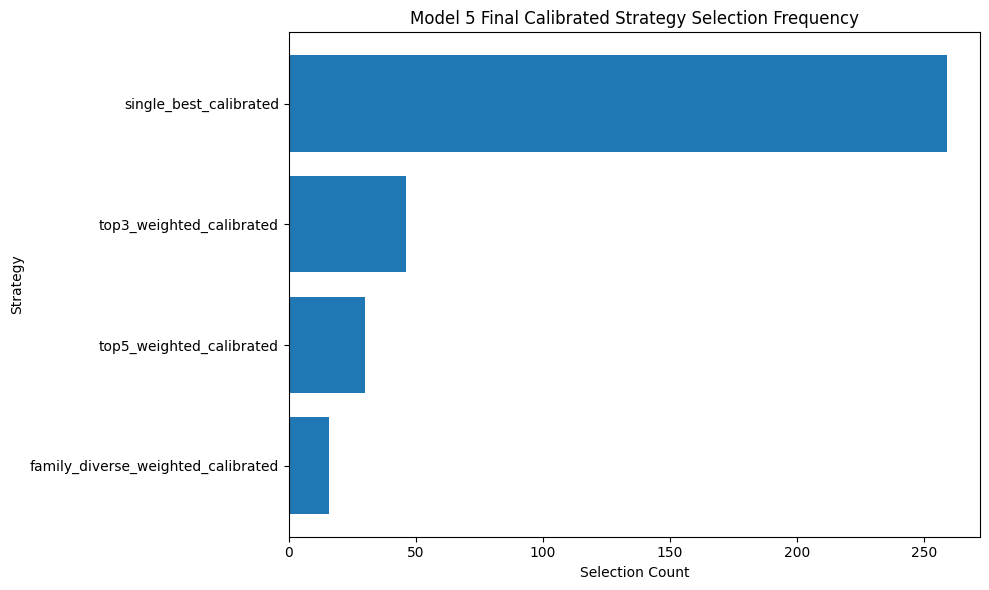

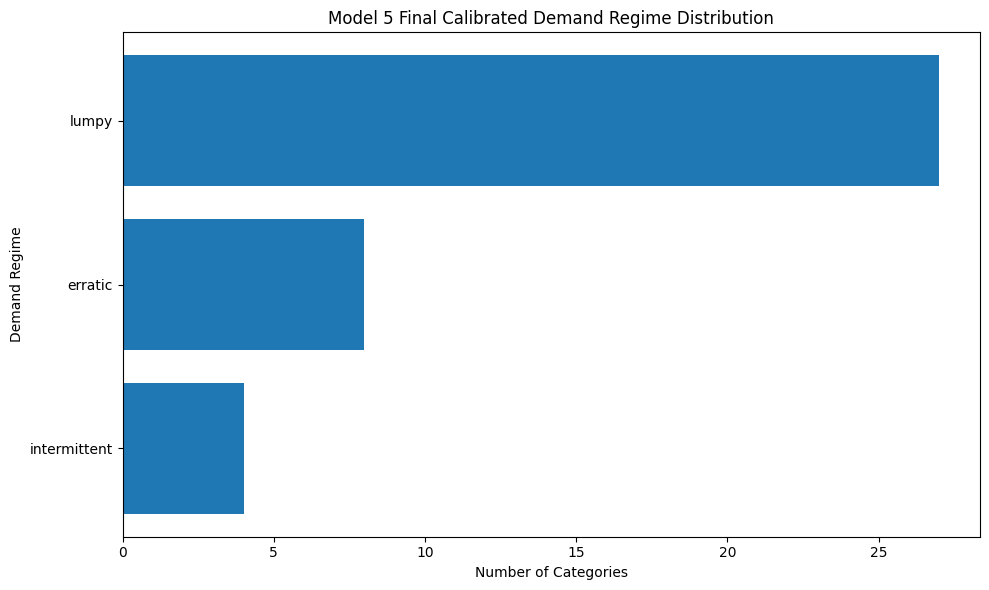

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(
    test_results_df["scenario"],
    test_results_df["mean_test_mase"],
    marker="o",
    label="Model 5 Final Calibrated"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Test MASE")
plt.xlabel("Split Scenario")
plt.title("Model 5 Final Calibrated Test MASE by Split Scenario")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_test_mase_by_scenario.png"), dpi=300)
plt.show()


plt.figure(figsize=(10, 6))
plt.boxplot(category_mean_results_df["mean_test_mase"].dropna())
plt.ylabel("Mean Test MASE")
plt.title("Model 5 Final Calibrated Category-Level Mean Test MASE Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_category_mase_distribution.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 7))
worst_plot = category_mean_results_df.head(10).sort_values("mean_test_mase")
plt.barh(worst_plot["category"], worst_plot["mean_test_mase"])
plt.xlabel("Mean Test MASE")
plt.ylabel("Product Category")
plt.title("Model 5 Final Calibrated Top 10 Worst Categories by Mean Test MASE")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_top10_worst_categories.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 7))
expert_plot = expert_selection_counts_df.head(20).sort_values("selection_count")
plt.barh(expert_plot["expert_name"], expert_plot["selection_count"])
plt.xlabel("Selection Count")
plt.ylabel("Expert")
plt.title("Model 5 Final Calibrated Expert Selection Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_expert_selection_frequency.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
strategy_plot = strategy_selection_counts_df.sort_values("selection_count")
plt.barh(strategy_plot["strategy"], strategy_plot["selection_count"])
plt.xlabel("Selection Count")
plt.ylabel("Strategy")
plt.title("Model 5 Final Calibrated Strategy Selection Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_strategy_selection_frequency.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
regime_plot = regime_counts_df.sort_values("category_count")
plt.barh(regime_plot["demand_regime"], regime_plot["category_count"])
plt.xlabel("Number of Categories")
plt.ylabel("Demand Regime")
plt.title("Model 5 Final Calibrated Demand Regime Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_5_demand_regime_distribution.png"), dpi=300)
plt.show()

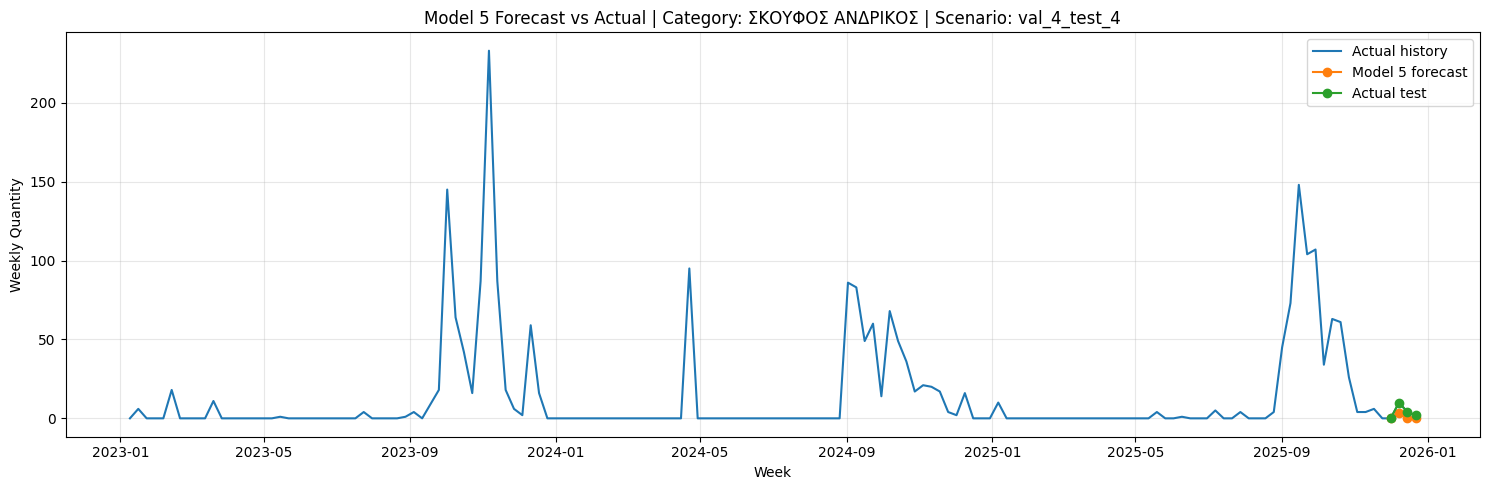

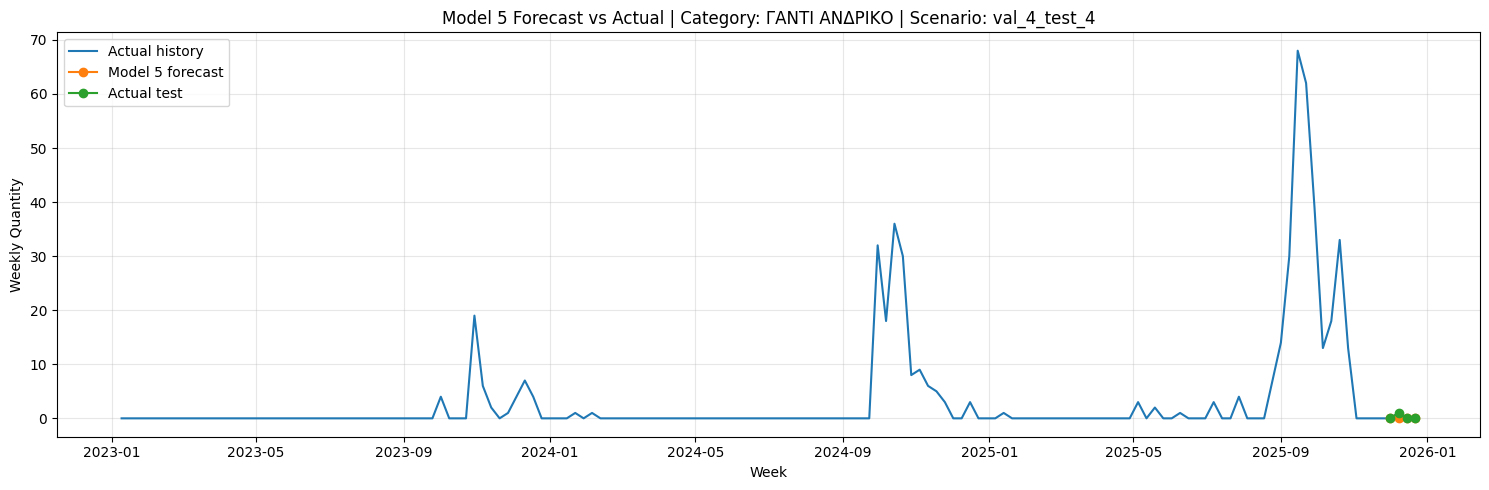

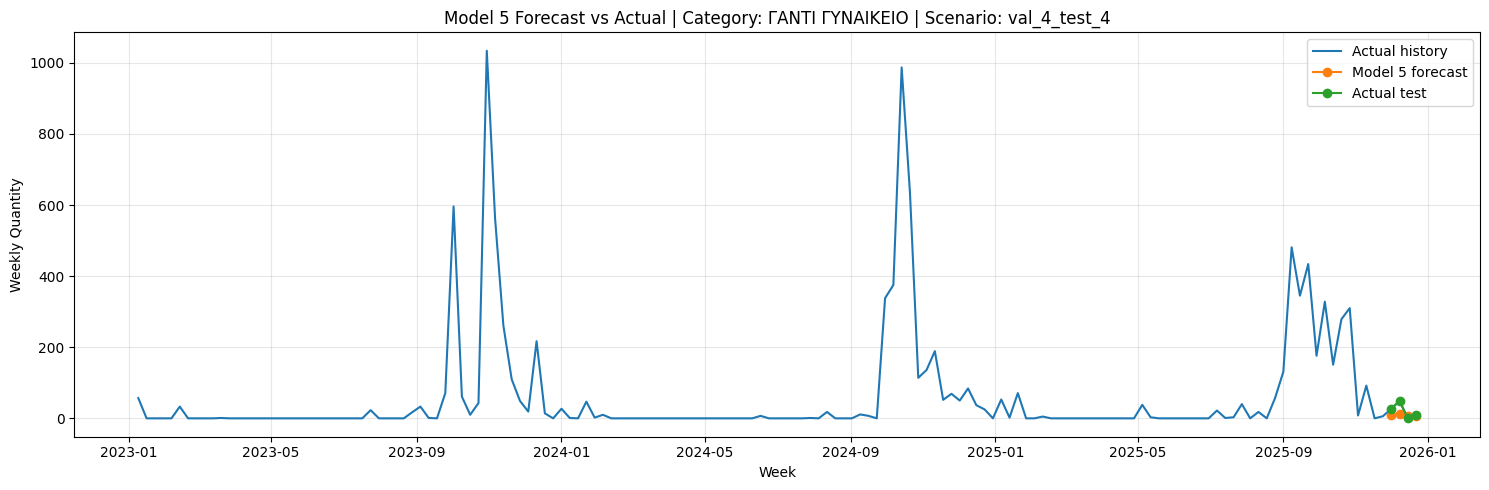

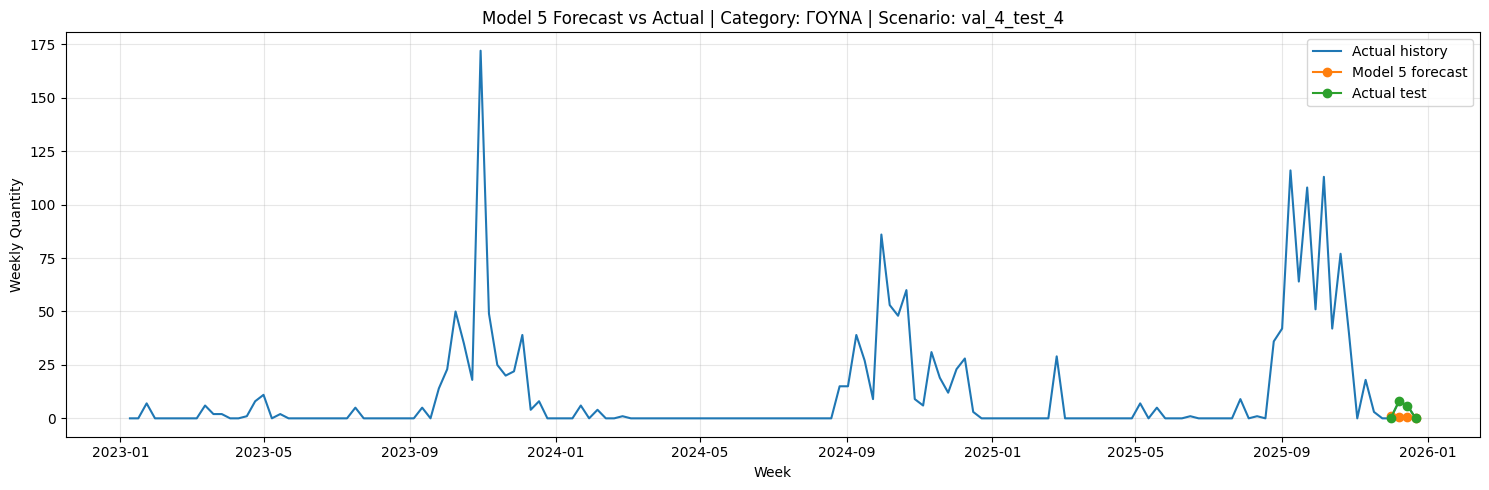

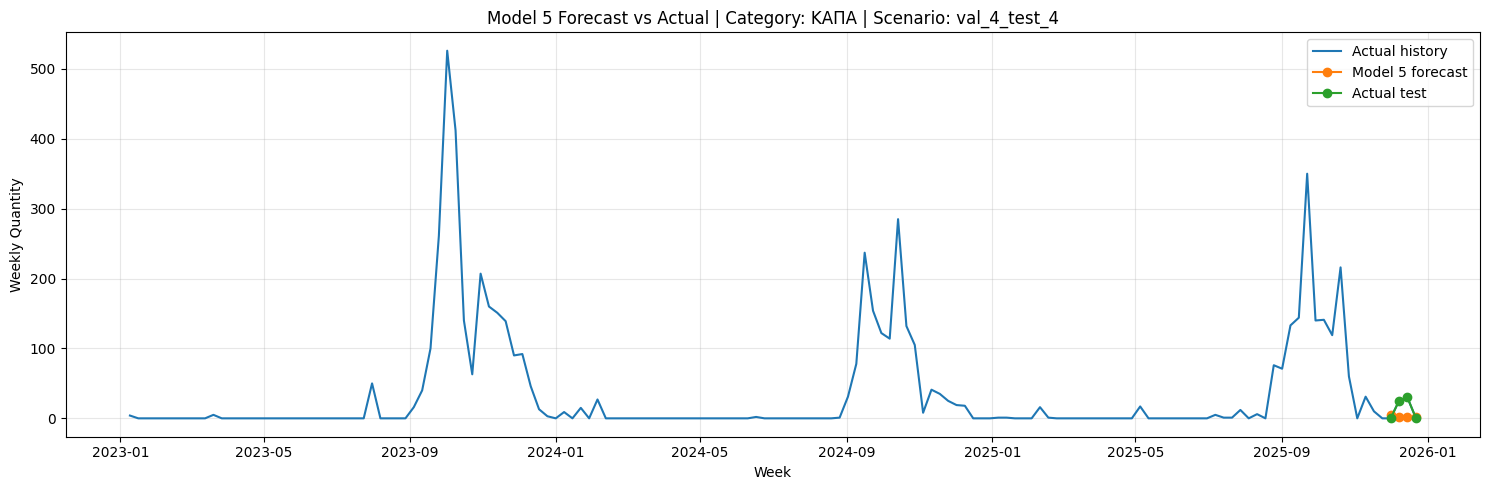

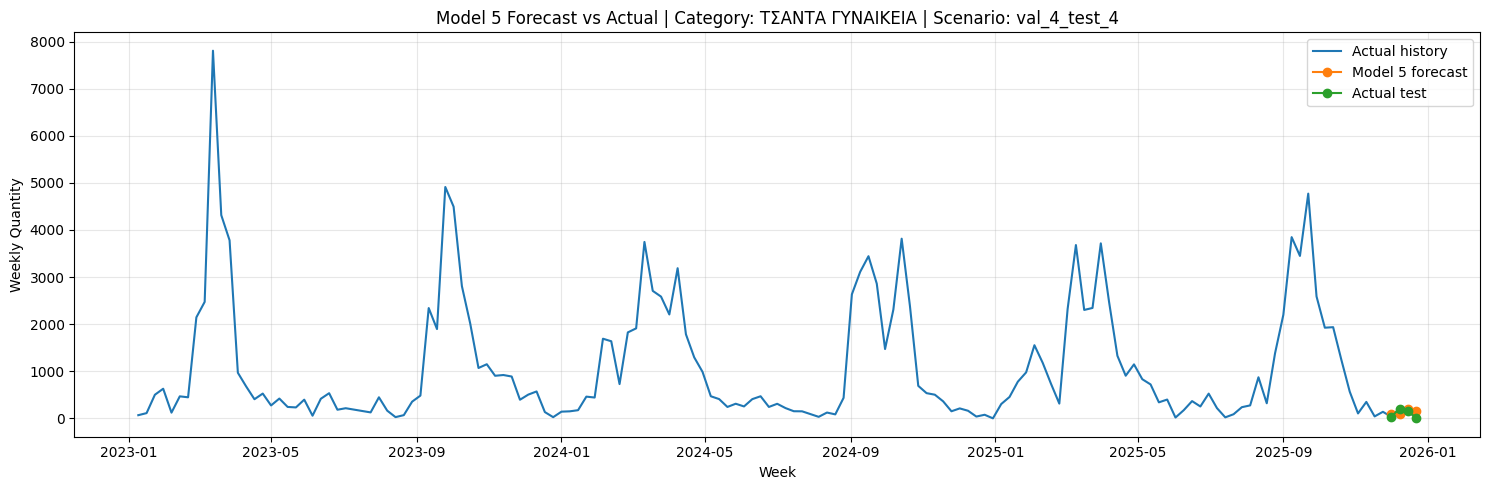

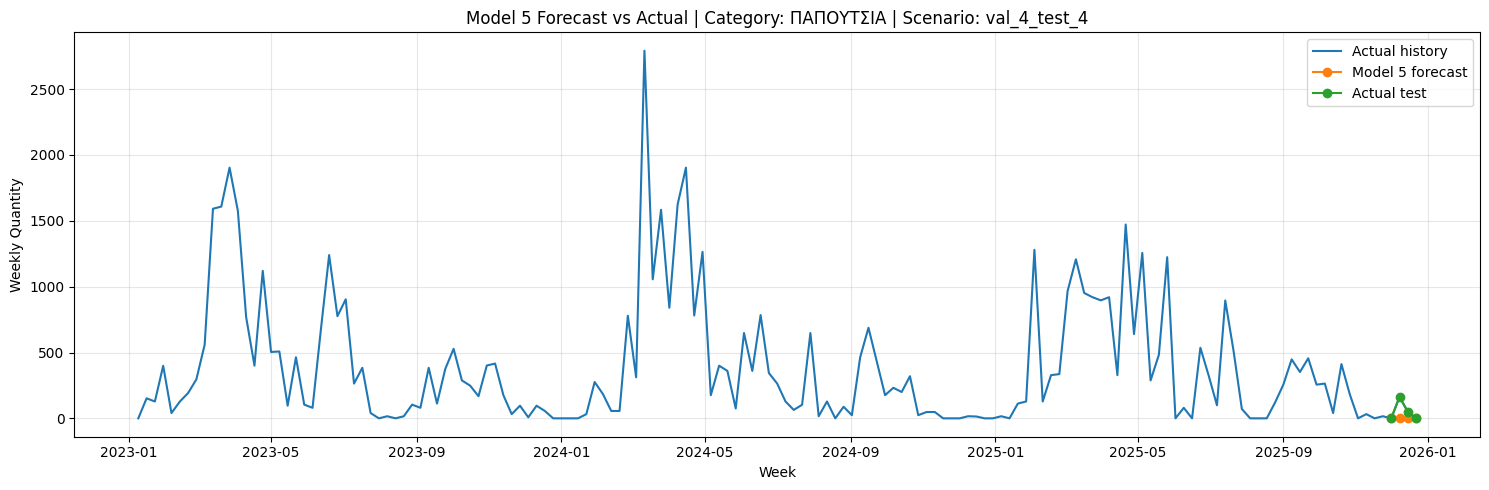

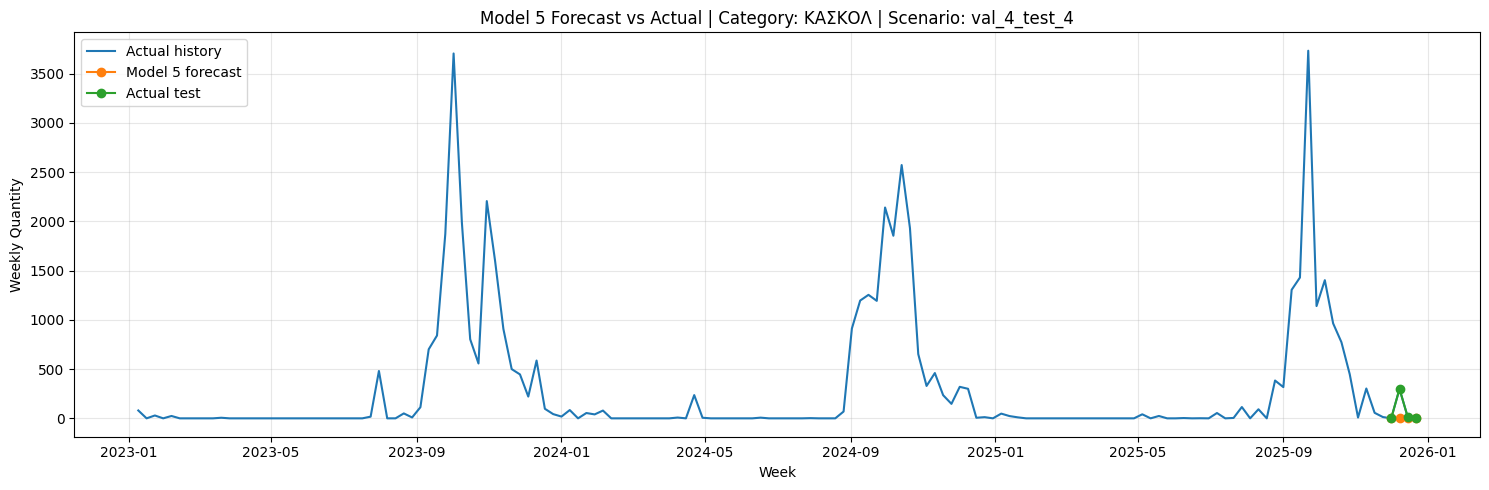

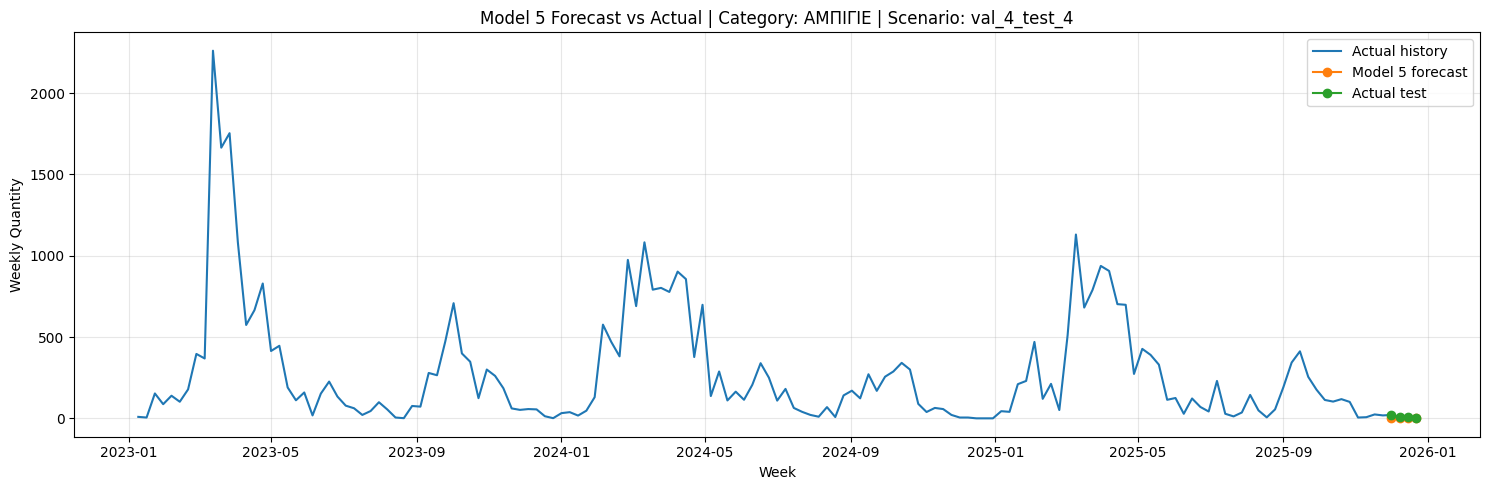

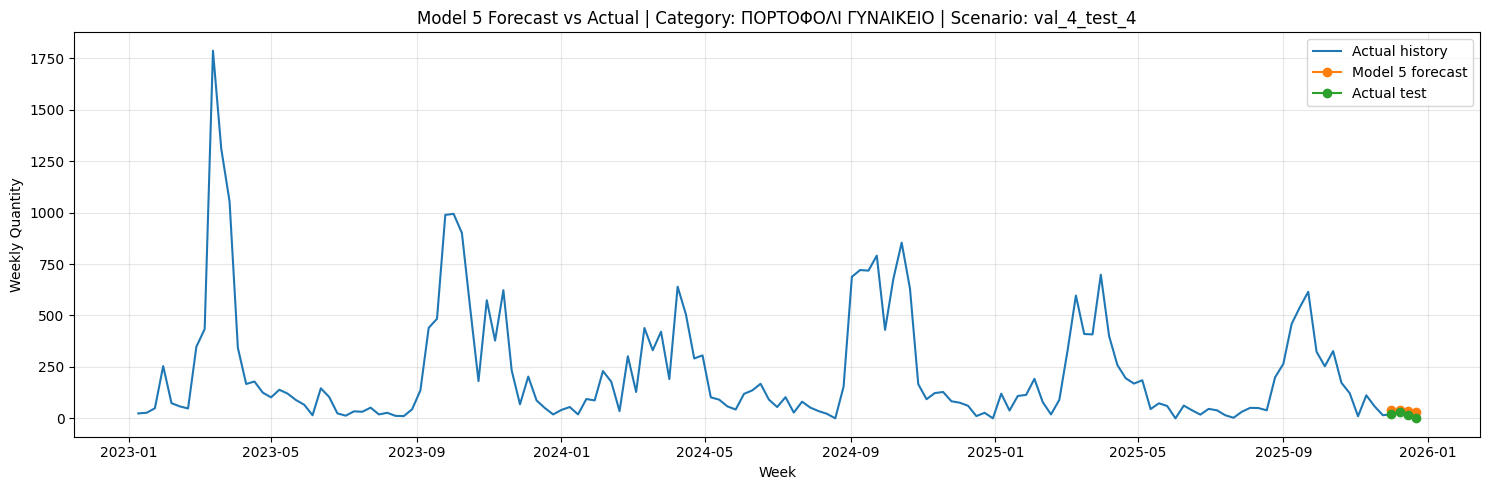


All Model 5 calibrated outputs saved to:
/content/drive/MyDrive/model_5_final_outputs


In [31]:
important_categories = (
    category_mean_results_df
    .sort_values("mean_test_mase", ascending=False)
    .head(5)["category"]
    .tolist()
)

top_volume_categories = (
    audit_df
    .sort_values("total_quantity", ascending=False)
    .head(5)["category"]
    .tolist()
)

plot_categories = list(dict.fromkeys(important_categories + top_volume_categories))

selected_plot_scenario = test_results_df.sort_values("mean_test_mase").iloc[0]["scenario"]

for cat in plot_categories:
    temp_pred = predictions_df[
        (predictions_df["category"] == cat) &
        (predictions_df["scenario"] == selected_plot_scenario)
    ].copy()

    temp_hist = panel[panel["category"] == cat].copy()

    if len(temp_pred) == 0:
        continue

    plt.figure(figsize=(15, 5))
    plt.plot(temp_hist["week"], temp_hist["y"], label="Actual history")
    plt.plot(temp_pred["week"], temp_pred["forecast"], marker="o", label="Model 5 forecast")
    plt.plot(temp_pred["week"], temp_pred["actual"], marker="o", label="Actual test")
    plt.title(f"Model 5 Forecast vs Actual | Category: {cat} | Scenario: {selected_plot_scenario}")
    plt.xlabel("Week")
    plt.ylabel("Weekly Quantity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    safe_cat = str(cat).replace("/", "_").replace("\\", "_").replace(" ", "_")
    plt.savefig(os.path.join(OUTPUT_DIR, f"model_5_forecast_vs_actual_{safe_cat}.png"), dpi=300)
    plt.show()
print("\nAll Model 5 calibrated outputs saved to:")
print(OUTPUT_DIR)